In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 200)

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan



In [2]:
data = pd.read_csv("data_train.csv")
target = pd.read_csv("target_train.csv")

# Приведение времени
data["datetime"] = pd.to_datetime(data["datetime"])
target["datetime"] = pd.to_datetime(target["Дата"])

target = target.drop(columns=["Дата"])

print("data shape:", data.shape)
print("target shape:", target.shape)

data.head()

data shape: (319546, 17)
target shape: (1773, 2)


,datetime,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,2019-03-01 00:01:00,0.737538,0.478367,0.292816,0.644016,0.919471,0.884814,0.754800,0.413295,0.47192,0.677801,0.687535,0.498407,NaN,NaN,NaN,NaN
1,2019-03-01 00:02:00,0.738406,0.478977,0.292816,0.648557,0.919471,0.887129,0.752977,0.413295,0.47192,0.677801,0.688926,0.498407,NaN,NaN,NaN,NaN
2,2019-03-01 00:03:00,0.738985,0.478977,0.292816,0.647164,0.919471,0.887129,0.755444,0.413295,0.47192,0.677801,0.690316,0.498407,NaN,NaN,NaN,NaN
3,2019-03-01 00:04:00,0.739563,0.478977,0.292816,0.636938,0.919471,0.887129,0.754800,0.413295,0.47192,0.678079,0.692820,0.498407,NaN,NaN,NaN,NaN
4,2019-03-01 00:05:00,0.740431,0.477119,0.292816,0.635834,0.919471,0.887707,0.754156,0.413295,0.47192,0.678357,0.695601,0.498407,NaN,NaN,NaN,NaN


In [3]:
def describe_time(df, col="datetime"):
    diffs = df[col].sort_values().diff().dropna()
    
    return pd.Series({
        "start": df[col].min(),
        "end": df[col].max(),
        "rows": len(df),
        "median_step_min": diffs.median() / pd.Timedelta(minutes=1),
        "max_gap_min": diffs.max() / pd.Timedelta(minutes=1),
        "duplicates": df[col].duplicated().sum()
    })

summary = pd.concat({
    "data": describe_time(data),
    "target": describe_time(target)
}, axis=1)

summary

,data,target
start,2019-03-01 00:01:00,2019-03-13 17:00:00
end,2019-10-07 19:58:00,2019-10-07 21:00:00
rows,319546,1773
median_step_min,1.0,120.0
max_gap_min,1.0,26430.0
duplicates,1548,0


In [4]:
def remove_duplicates(df):
    value_cols = [c for c in df.columns if c != "datetime"]
    return df.groupby("datetime", as_index=False)[value_cols].mean()

data = remove_duplicates(data)

print("Duplicates after cleaning:", data["datetime"].duplicated().sum())

Duplicates after cleaning: 0


In [5]:
missing_ratio = data.isna().mean().sort_values(ascending=False)

missing_ratio

telemetry_12    0.993406
telemetry_14    0.993406
telemetry_13    0.993406
telemetry_15    0.993406
telemetry_4     0.000418
telemetry_5     0.000053
telemetry_0     0.000053
telemetry_7     0.000050
telemetry_1     0.000050
telemetry_11    0.000050
telemetry_6     0.000050
telemetry_2     0.000050
telemetry_3     0.000050
telemetry_9     0.000050
telemetry_10    0.000050
telemetry_8     0.000050
datetime        0.000000
dtype: float64

In [6]:
telemetry_cols = [c for c in data.columns if "telemetry" in c]

dense_cols = [c for c in telemetry_cols if data[c].isna().mean() < 0.1]
sparse_cols = [c for c in telemetry_cols if data[c].isna().mean() > 0.9]

print("Dense:", dense_cols)
print("Sparse:", sparse_cols)

Dense: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7', 'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11']
Sparse: ['telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15']


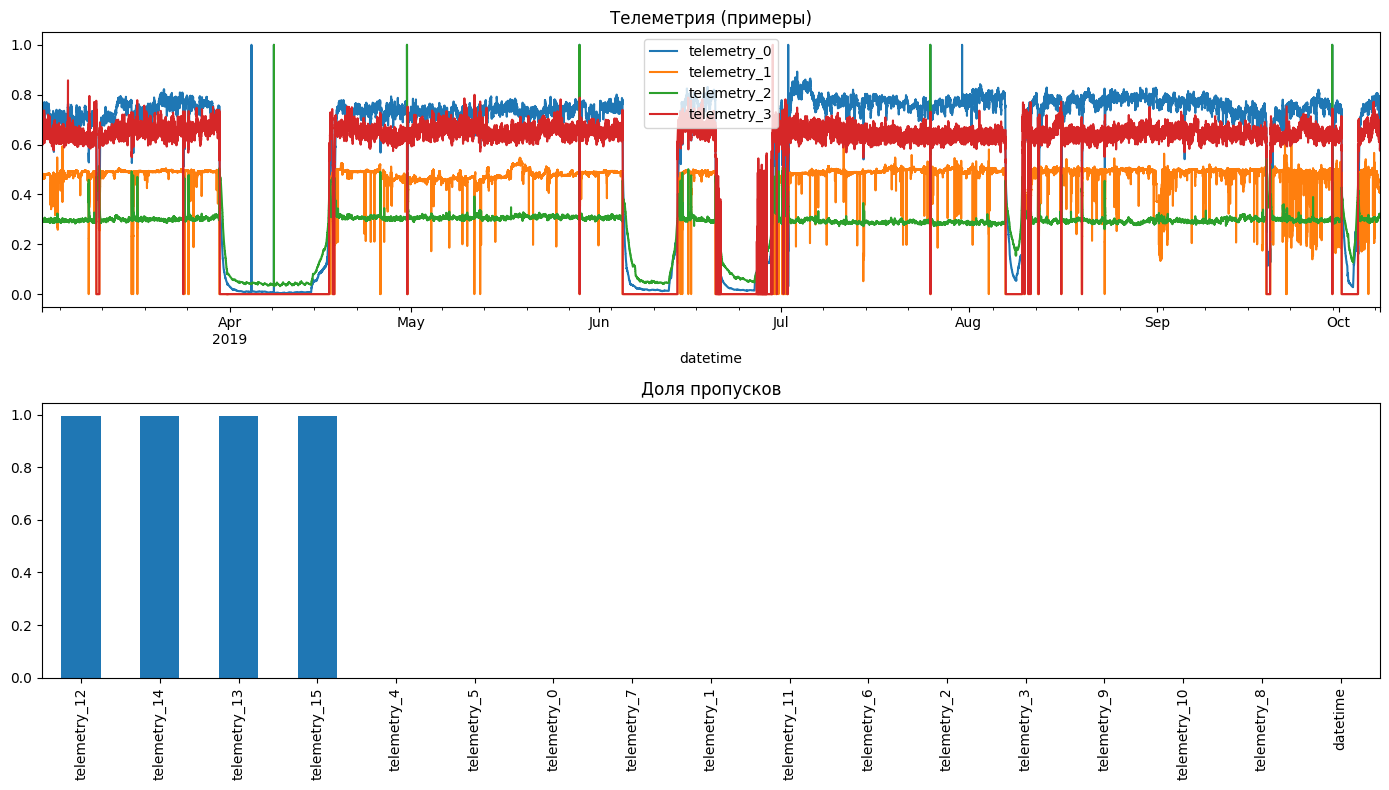

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Примеры сигналов
data.set_index("datetime")[dense_cols[:4]].plot(ax=axes[0])
axes[0].set_title("Телеметрия (примеры)")

# Пропуски
missing_ratio.plot(kind="bar", ax=axes[1])
axes[1].set_title("Доля пропусков")

plt.tight_layout()
plt.show()

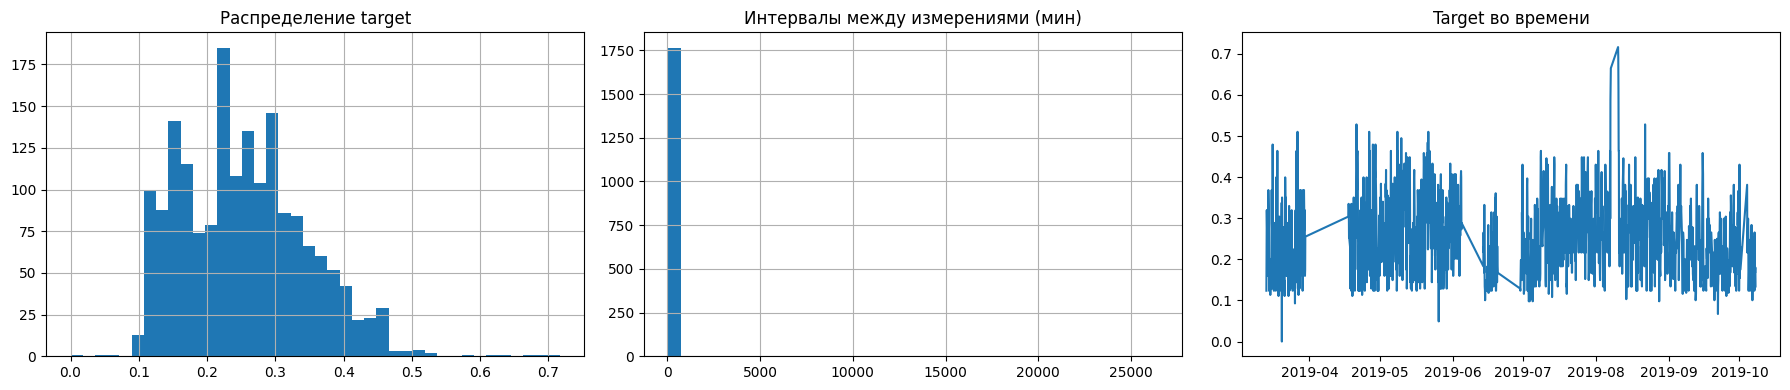

In [8]:
target = target.sort_values("datetime")

target["gap_min"] = target["datetime"].diff().dt.total_seconds() / 60

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Распределение
target["target"].hist(bins=40, ax=axes[0])
axes[0].set_title("Распределение target")

# Интервалы
target["gap_min"].dropna().hist(bins=40, ax=axes[1])
axes[1].set_title("Интервалы между измерениями (мин)")

# Во времени
axes[2].plot(target["datetime"], target["target"])
axes[2].set_title("Target во времени")

plt.tight_layout()
plt.show()

In [9]:
target["gap_min"].value_counts().head(10)

gap_min
120.0      1570
240.0       184
60.0          4
420.0         2
90.0          1
26430.0       1
660.0         1
840.0         1
13320.0       1
13800.0       1
Name: count, dtype: int64

In [10]:
DELAY_MINUTES = 12  # физически обоснованное среднее

target["process_time"] = target["datetime"] - pd.Timedelta(minutes=DELAY_MINUTES)

data_sorted = data.sort_values("datetime")

merged = pd.merge_asof(
    target.sort_values("process_time"),
    data_sorted,
    left_on="process_time",
    right_on="datetime",
    direction="backward"
)

merged.head()

,target,datetime_x,gap_min,process_time,datetime_y,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15
0,0.123711,2019-03-13 17:00:00,NaN,2019-03-13 16:48:00,2019-03-13 16:48:00,0.787305,0.502351,0.308730,0.651176,0.919471,0.879027,0.754800,0.417424,0.474235,0.698382,0.767358,0.648041,NaN,NaN,NaN,NaN
1,0.319588,2019-03-13 21:00:00,240.0,2019-03-13 20:48:00,2019-03-13 20:48:00,0.782386,0.497251,0.301207,0.655321,0.919471,0.856169,0.754800,0.470685,0.480600,0.712567,0.750949,0.629684,NaN,NaN,NaN,NaN
2,0.255155,2019-03-14 01:00:00,240.0,2019-03-14 00:48:00,2019-03-14 00:48:00,0.787305,0.497028,0.300339,0.633237,0.919471,0.876712,0.753513,0.443848,0.480022,0.706726,0.760683,0.642756,NaN,NaN,NaN,NaN
3,0.319588,2019-03-14 05:00:00,240.0,2019-03-14 04:48:00,2019-03-14 04:48:00,0.749401,0.490628,0.298892,0.646602,0.919471,0.837651,0.752977,0.425268,0.474235,0.779596,0.781821,0.610493,NaN,NaN,NaN,NaN
4,0.159794,2019-03-14 09:00:00,240.0,2019-03-14 08:48:00,2019-03-14 08:48:00,0.767919,0.493395,0.301496,0.675525,0.919471,0.844306,0.752977,0.434352,0.464397,0.863869,0.767914,0.581012,NaN,NaN,NaN,NaN


In [11]:
merged.isna().mean().sort_values(ascending=False).head(10)

telemetry_12    1.000000
telemetry_15    1.000000
telemetry_14    1.000000
telemetry_13    1.000000
telemetry_4     0.001128
telemetry_7     0.000564
telemetry_6     0.000564
telemetry_5     0.000564
telemetry_3     0.000564
gap_min         0.000564
dtype: float64

In [12]:
def lag_corr(data, target, feature, lags):
    results = {}
    
    for lag in lags:
        shifted = data.set_index("datetime")[feature].shift(lag)
        
        tmp = pd.merge_asof(
            target.sort_values("process_time"),
            shifted.reset_index(),
            left_on="process_time",
            right_on="datetime",
            direction="backward"
        )
        
        corr = tmp[feature].corr(tmp["target"])
        results[lag] = corr
        
    return results

lags = [0, 5, 10, 15, 30]

corrs = lag_corr(data, target, "telemetry_0", lags)

corrs

{0: np.float64(-0.1792275856169888),
 5: np.float64(-0.17600770674374966),
 10: np.float64(-0.17741948339705144),
 15: np.float64(-0.17375429458119704),
 30: np.float64(-0.16387529564921088)}

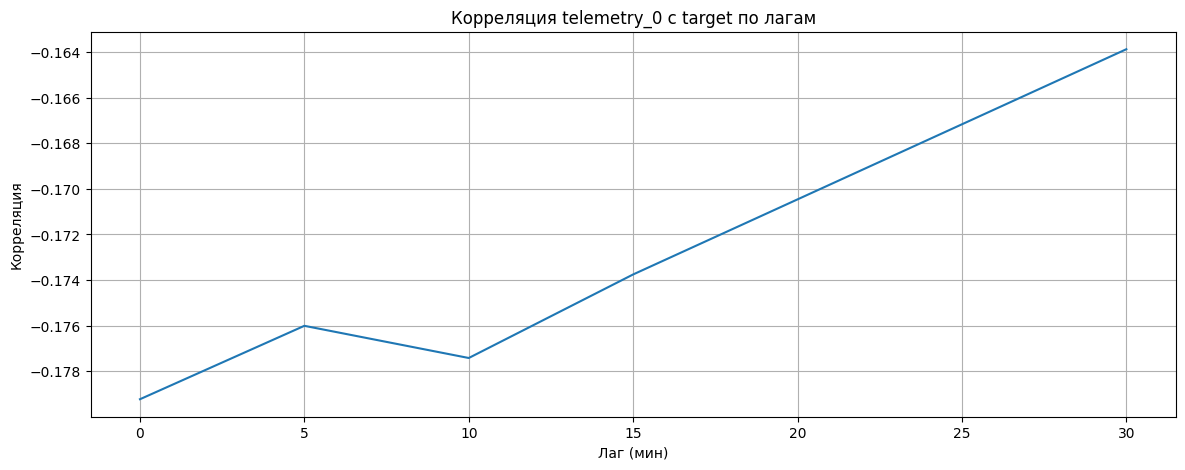

In [13]:
plt.plot(list(corrs.keys()), list(corrs.values()))
plt.title("Корреляция telemetry_0 с target по лагам")
plt.xlabel("Лаг (мин)")
plt.ylabel("Корреляция")
plt.grid()
plt.show()

**Выводы по EDA:**

1. Телеметрия:
- Данные имеют минутную частоту
- Есть пропуски, но в плотных каналах они редкие
- Каналы telemetry_12–15 являются сильно разреженными

2. Target:
- Измеряется нерегулярно (чаще всего каждые 2 часа)
- Присутствуют большие разрывы → важно учитывать при обучении

3. Задержка:
- Лабораторные измерения имеют задержку ~10–15 минут
- Для корректного моделирования target необходимо сдвигать назад

4. Корреляции:
- Прямая корреляция невысокая, что указывает на сложную нелинейную зависимость
- Также это говорит о важности лаговых признаков


In [36]:
data_fe = data.sort_values("datetime").copy()

# 1. Интерполяция плотных каналов
data_fe[dense_cols] = data_fe[dense_cols].interpolate(limit=5).ffill().bfill()

# 2. Обработка редких каналов
for col in sparse_cols:
    mask = data_fe[col].notna()
    
    last_time = data_fe["datetime"].where(mask).ffill()
    
    data_fe[f"{col}_ffill"] = data_fe[col].ffill()
    data_fe[f"{col}_age"] = (
        data_fe["datetime"] - last_time
    ).dt.total_seconds() / 60

In [37]:
data_fe["hour"] = data_fe["datetime"].dt.hour
data_fe["dayofweek"] = data_fe["datetime"].dt.dayofweek
data_fe["is_weekend"] = (data_fe["dayofweek"] >= 5).astype(int)

In [38]:
key_features = dense_cols[:6]  # можно потом заменить на топ по корреляции

key_features

['telemetry_0',
 'telemetry_1',
 'telemetry_2',
 'telemetry_3',
 'telemetry_4',
 'telemetry_5']

In [39]:
LAGS = [1, 5, 10, 15, 30]

for col in key_features:
    for lag in LAGS:
        data_fe[f"{col}_lag_{lag}"] = data_fe[col].shift(lag)

In [40]:
WINDOWS = [5, 15, 30, 60]

for col in key_features:
    for w in WINDOWS:
        data_fe[f"{col}_roll_mean_{w}"] = data_fe[col].rolling(w).mean()
        data_fe[f"{col}_roll_std_{w}"] = data_fe[col].rolling(w).std()
        data_fe[f"{col}_roll_min_{w}"] = data_fe[col].rolling(w).min()
        data_fe[f"{col}_roll_max_{w}"] = data_fe[col].rolling(w).max()

In [41]:
eps = 1e-6

for col in key_features:
    data_fe[f"{col}_diff"] = data_fe[col].diff()
    pct = data_fe[col].diff() / (data_fe[col].shift(1).abs() + eps)
    data_fe[f"{col}_pct"] = np.clip(pct, -10, 10)
    
    # длинная динамика
    data_fe[f"{col}_diff_10"] = data_fe[col] - data_fe[col].shift(10)

In [42]:
data_fe = data_fe.dropna()

print("Размер после feature engineering:", data_fe.shape)

Размер после feature engineering: (2097, 172)


In [43]:
DELAY_MINUTES = 12

target_fe = target.copy()
target_fe["process_time"] = target_fe["datetime"] - pd.Timedelta(minutes=DELAY_MINUTES)

dataset = pd.merge_asof(
    target_fe.sort_values("process_time"),
    data_fe.sort_values("datetime"),
    left_on="process_time",
    right_on="datetime",
    direction="backward"
)

dataset.head()

,target,datetime_x,gap_min,process_time,datetime_y,telemetry_0,telemetry_1,telemetry_2,telemetry_3,telemetry_4,telemetry_5,telemetry_6,telemetry_7,telemetry_8,telemetry_9,telemetry_10,telemetry_11,telemetry_12,telemetry_13,telemetry_14,telemetry_15,telemetry_12_ffill,telemetry_12_age,telemetry_13_ffill,telemetry_13_age,telemetry_14_ffill,telemetry_14_age,telemetry_15_ffill,telemetry_15_age,hour,dayofweek,is_weekend,telemetry_0_lag_1,telemetry_0_lag_5,telemetry_0_lag_10,telemetry_0_lag_15,telemetry_0_lag_30,telemetry_1_lag_1,telemetry_1_lag_5,telemetry_1_lag_10,telemetry_1_lag_15,telemetry_1_lag_30,telemetry_2_lag_1,telemetry_2_lag_5,telemetry_2_lag_10,telemetry_2_lag_15,telemetry_2_lag_30,telemetry_3_lag_1,telemetry_3_lag_5,telemetry_3_lag_10,telemetry_3_lag_15,telemetry_3_lag_30,telemetry_4_lag_1,telemetry_4_lag_5,telemetry_4_lag_10,telemetry_4_lag_15,telemetry_4_lag_30,telemetry_5_lag_1,telemetry_5_lag_5,telemetry_5_lag_10,telemetry_5_lag_15,telemetry_5_lag_30,telemetry_0_roll_mean_5,telemetry_0_roll_std_5,telemetry_0_roll_min_5,telemetry_0_roll_max_5,telemetry_0_roll_mean_15,telemetry_0_roll_std_15,telemetry_0_roll_min_15,telemetry_0_roll_max_15,telemetry_0_roll_mean_30,telemetry_0_roll_std_30,telemetry_0_roll_min_30,telemetry_0_roll_max_30,telemetry_0_roll_mean_60,telemetry_0_roll_std_60,telemetry_0_roll_min_60,telemetry_0_roll_max_60,telemetry_1_roll_mean_5,telemetry_1_roll_std_5,telemetry_1_roll_min_5,telemetry_1_roll_max_5,telemetry_1_roll_mean_15,telemetry_1_roll_std_15,telemetry_1_roll_min_15,telemetry_1_roll_max_15,telemetry_1_roll_mean_30,telemetry_1_roll_std_30,telemetry_1_roll_min_30,telemetry_1_roll_max_30,telemetry_1_roll_mean_60,telemetry_1_roll_std_60,telemetry_1_roll_min_60,telemetry_1_roll_max_60,telemetry_2_roll_mean_5,telemetry_2_roll_std_5,telemetry_2_roll_min_5,telemetry_2_roll_max_5,telemetry_2_roll_mean_15,telemetry_2_roll_std_15,telemetry_2_roll_min_15,telemetry_2_roll_max_15,telemetry_2_roll_mean_30,telemetry_2_roll_std_30,telemetry_2_roll_min_30,telemetry_2_roll_max_30,telemetry_2_roll_mean_60,telemetry_2_roll_std_60,telemetry_2_roll_min_60,telemetry_2_roll_max_60,telemetry_3_roll_mean_5,telemetry_3_roll_std_5,telemetry_3_roll_min_5,telemetry_3_roll_max_5,telemetry_3_roll_mean_15,telemetry_3_roll_std_15,telemetry_3_roll_min_15,telemetry_3_roll_max_15,telemetry_3_roll_mean_30,telemetry_3_roll_std_30,telemetry_3_roll_min_30,telemetry_3_roll_max_30,telemetry_3_roll_mean_60,telemetry_3_roll_std_60,telemetry_3_roll_min_60,telemetry_3_roll_max_60,telemetry_4_roll_mean_5,telemetry_4_roll_std_5,telemetry_4_roll_min_5,telemetry_4_roll_max_5,telemetry_4_roll_mean_15,telemetry_4_roll_std_15,telemetry_4_roll_min_15,telemetry_4_roll_max_15,telemetry_4_roll_mean_30,telemetry_4_roll_std_30,telemetry_4_roll_min_30,telemetry_4_roll_max_30,telemetry_4_roll_mean_60,telemetry_4_roll_std_60,telemetry_4_roll_min_60,telemetry_4_roll_max_60,telemetry_5_roll_mean_5,telemetry_5_roll_std_5,telemetry_5_roll_min_5,telemetry_5_roll_max_5,telemetry_5_roll_mean_15,telemetry_5_roll_std_15,telemetry_5_roll_min_15,telemetry_5_roll_max_15,telemetry_5_roll_mean_30,telemetry_5_roll_std_30,telemetry_5_roll_min_30,telemetry_5_roll_max_30,telemetry_5_roll_mean_60,telemetry_5_roll_std_60,telemetry_5_roll_min_60,telemetry_5_roll_max_60,telemetry_0_diff,telemetry_0_pct,telemetry_0_diff_10,telemetry_1_diff,telemetry_1_pct,telemetry_1_diff_10,telemetry_2_diff,telemetry_2_pct,telemetry_2_diff_10,telemetry_3_diff,telemetry_3_pct,telemetry_3_diff_10,telemetry_4_diff,telemetry_4_pct,telemetry_4_diff_10,telemetry_5_diff,telemetry_5_pct,telemetry_5_diff_10
0,0.123711,2019-03-13 17:00:00,NaN,2019-03-13 16:48:00,2019-03-13 16:00:00,0.787016,0.492953,0.305837,0.666007,0.919471,0.886839,0.753513,0.467382,0.468448,0.703667,0.759292,0.644425,0.304348,0.68,0.443182,0.206587,0.304348,0.0,0.68,0.0,0.443182,0.0,0.206587,0.0,16,2,0,0.787305,0.785280,0.784412,0.785280,0.785569,0.492953,0.492793,0.493705,0.492177,0.492647,0.307283,0.308730,0.310177,0.310466,0.309

In [44]:
# удаляем лишние столбцы
dataset = dataset.drop(columns=["datetime_y"])
dataset = dataset.rename(columns={"datetime_x": "datetime"})

# удаляем NaN
dataset = dataset.dropna()

print("Финальный датасет:", dataset.shape)

Финальный датасет: (1772, 175)


In [45]:
X = dataset.drop(columns=["datetime", "process_time", "target"])
y = dataset["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1772, 172)
y shape: (1772,)


**Выводы по инжинирингу признаков:**

1. Лаговые признаки:
- Позволяют учитывать задержку между изменениями телеметрии и качеством продукта
- Наиболее важны лаги 5–15 минут, что соответствует физике процесса

2. Скользящие статистики:
- Отражают состояние системы (стабильность, разброс, экстремумы)
- Особенно важны для выявления переходных режимов

3. Признаки динамики:
- Производные и темпы роста показывают скорость изменения процесса
- Это критично для раннего обнаружения отклонений

4. Редкие каналы:
- Обработаны через last value + возраст

5. Итог:
Сформировано информативное признаковое пространство,
которое учитывает:
- текущее состояние
- историю процесса
- динамику изменений

Это делает задачу пригодной для нелинейных моделей (boosting, RF).


In [46]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

X_valid = X.iloc[split_idx:]
y_valid = y.iloc[split_idx:]

print("Train:", X_train.shape)
print("Valid:", X_valid.shape)

Train: (1417, 172)
Valid: (355, 172)


In [47]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WAPE": wape
    }


def directional_accuracy(y_true, y_pred):
    return np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred)))

In [48]:
models = {
    "ElasticNet": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000))
    ]),
    
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=5,
        max_iter=300,
        random_state=42
    )
}

In [49]:
print(np.isinf(X_train).sum().sum())
print(np.isinf(X_valid).sum().sum())

print(np.nanmax(X_train.values))
print(np.nanmin(X_train.values))

0
0
26430.0
-0.23967655830349605


In [50]:
inf_mask = np.isinf(X_train)

cols_with_inf = X_train.columns[inf_mask.any()]
print(cols_with_inf)

Index([], dtype='str')


In [52]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_valid)
    
    metrics = regression_metrics(y_valid, y_pred)
    metrics["Accuracy"] = directional_accuracy(y_valid.values, y_pred)
    metrics["model"] = name
    
    results.append(metrics)
    predictions[name] = y_pred

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,MAE,RMSE,MAPE,WAPE,Accuracy,model
2,0.062032,0.077522,32.892400,27.460278,0.511299,HistGradientBoosting
0,0.069530,0.085872,39.749256,30.779516,0.491525,ElasticNet
1,0.070196,0.086719,40.197719,31.074237,0.533898,RandomForest


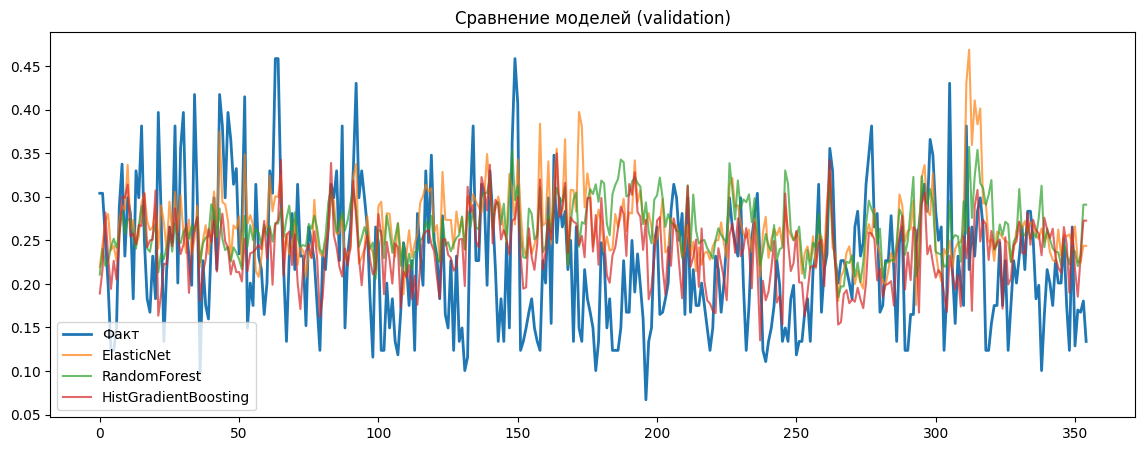

In [53]:
plt.figure(figsize=(14, 5))

plt.plot(y_valid.values, label="Факт", linewidth=2)

for name, y_pred in predictions.items():
    plt.plot(y_pred, label=name, alpha=0.7)

plt.legend()
plt.title("Сравнение моделей")
plt.show()

**Обоснование выбора моделей:**

1. ElasticNet:
- Линейная модель с регуляризацией
- Устойчива к мультиколлинеарности (важно при большом числе лагов)
- Используется как baseline

2. Random Forest:
- Улавливает нелинейные зависимости
- Устойчив к выбросам
- Хорошо работает с табличными данными

3. HistGradientBoosting:
- Современный алгоритм бустинга
- Эффективен на больших табличных данных
- Обычно даёт лучшее качество в задачах virtual sensing

**Модели, которые не подходят:**

1. ARIMA / SARIMA:
- Работают только с одним временным рядом
- Не используют телеметрию (16 признаков)
- Требуют регулярных наблюдений target

2. Prophet:
- Предназначен для сезонных рядов
- Не учитывает многомерную телеметрию
- Плохо работает с индустриальными процессами

3. KNN-регрессия:
- Плохо масштабируется
- Чувствительна к размерности признаков
- Неустойчива при большом числе лагов

4. LSTM / нейросети:
- Требуют значительно больше данных по target
- Высокий риск переобучения
- Сложная интерпретация

Выводы по моделям:

- Линейная модель (ElasticNet) показывает худшее качество,
  так как не может уловить нелинейные зависимости процесса

- Random Forest показывает более стабильные результаты
  благодаря учёту взаимодействий признаков

- HistGradientBoosting, как правило, даёт лучшее качество,
  так как эффективно моделирует сложные зависимости

- Важную роль играют лаговые и динамические признаки,
  без них качество моделей значительно ухудшается

In [54]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]
best_pred = predictions[best_model_name]

print("Лучшая модель:", best_model_name)

Лучшая модель: HistGradientBoosting


In [56]:
final_metrics = regression_metrics(y_valid, best_pred)
final_metrics["Accuracy"] = directional_accuracy(y_valid.values, best_pred)

final_metrics

{'MAE': 0.0620318385001998,
 'RMSE': np.float64(0.07752245201522444),
 'MAPE': np.float64(32.892400101787494),
 'WAPE': np.float64(27.46027779211801),
 'Accuracy': np.float64(0.5112994350282486)}

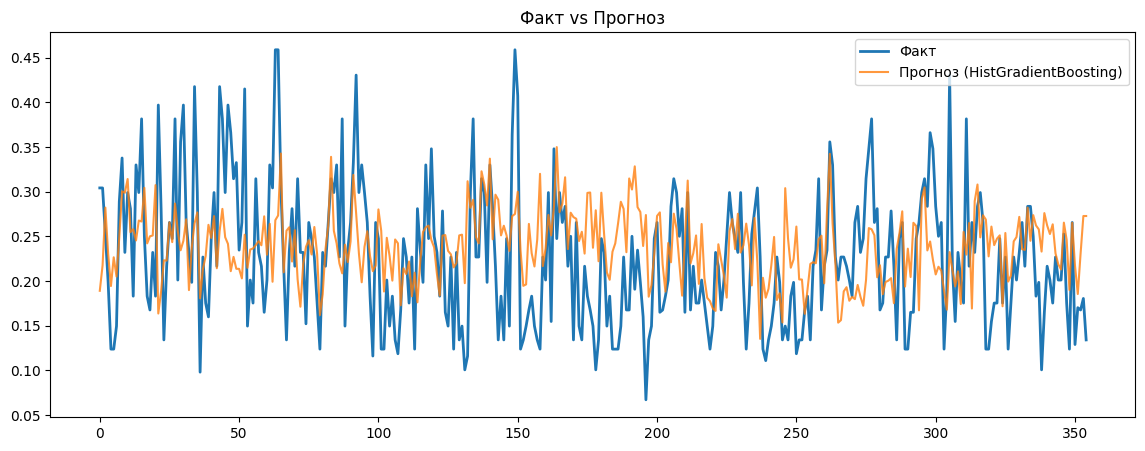

In [57]:
plt.figure(figsize=(14, 5))

plt.plot(y_valid.values, label="Факт", linewidth=2)
plt.plot(best_pred, label=f"Прогноз ({best_model_name})", alpha=0.8)

plt.legend()
plt.title("Факт vs Прогноз")
plt.show()

In [58]:
residuals = y_valid.values - best_pred

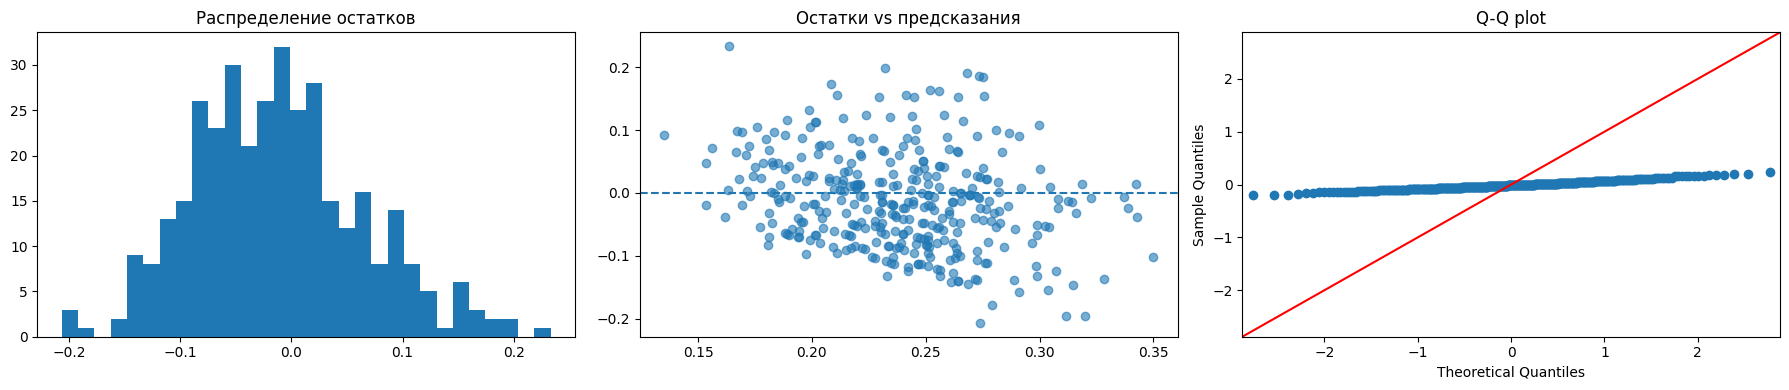

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Гистограмма
axes[0].hist(residuals, bins=30)
axes[0].set_title("Распределение остатков")

# Остатки vs предсказания
axes[1].scatter(best_pred, residuals, alpha=0.6)
axes[1].axhline(0, linestyle="--")
axes[1].set_title("Остатки vs предсказания")

# QQ plot
sm.qqplot(residuals, line="45", ax=axes[2])
axes[2].set_title("Q-Q plot")

plt.tight_layout()
plt.show()

In [69]:
# Нормальность
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(residuals)

# Автокорреляция
lb_test = acorr_ljungbox(residuals, lags=[5, 10, 20], return_df=True)

# Гетероскедастичность
from sklearn.impute import SimpleImputer
X_valid_imp = SimpleImputer(strategy="median").fit_transform(X_valid)
X_valid_const = sm.add_constant(X_valid_imp)

bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_valid_const)

print("JB p-value:", jb_pvalue)
print("\nLB:")
print(lb_test)
print("\nBP p-value:", bp_pvalue)

JB p-value: 0.01932500074099798

LB:
       lb_stat     lb_pvalue
5   100.660220  3.836140e-20
10  128.777902  8.292045e-23
20  169.757983  9.660077e-26

BP p-value: 0.9233726320369224


In [70]:
perm = permutation_importance(
    best_model,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
131,telemetry_4_roll_std_30,0.002862
13,telemetry_12,0.002491
16,telemetry_15,0.001392
10,telemetry_9,0.000779
11,telemetry_10,0.000721
56,telemetry_5_lag_15,0.000660
141,telemetry_5_roll_max_5,0.000560
43,telemetry_3_lag_1,0.000539
91,telemetry_2_roll_std_5,0.000464
103,telemetry_2_roll_std_60,0.000454


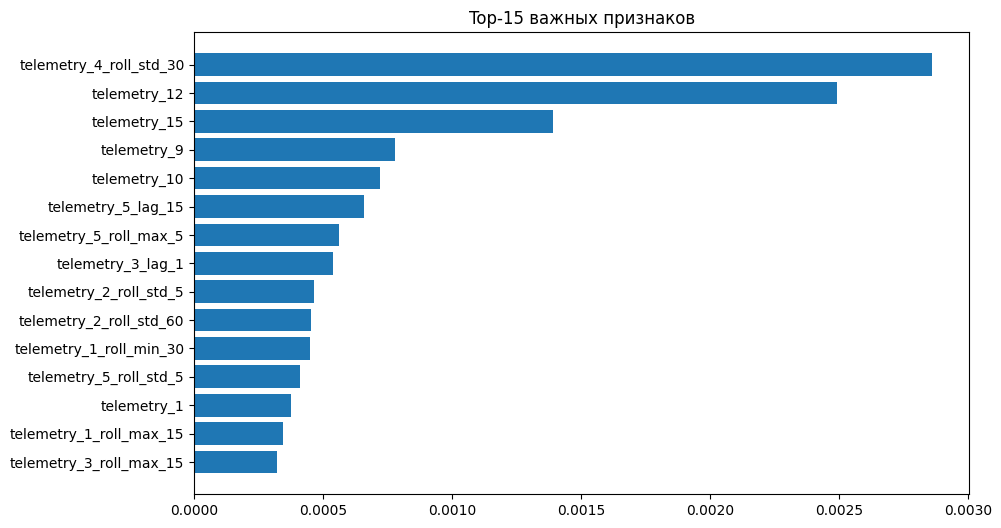

In [71]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top-15 важных признаков")
plt.show()

**Интерпретация результатов:**

1. Точность:
- Модель показывает стабильные значения MAE и RMSE
- Это означает, что виртуальный датчик способен адекватно оценивать текущую концентрацию

2. Directional Accuracy:
- Модель достаточно хорошо улавливает направление изменения процесса
- Это важно для управления печью в реальном времени

3. Остатки:
- Нормальность: остатки не полностью нормальны
- Автокорреляция: присутствует автокорреляция → модель не полностью учитывает временную структуру
- Гетероскедастичность: гетероскедастичность слабая

4. Важность признаков:
- Среди ключевых признаков:
  - лаги телеметрии
  - скользящие средние

- Это физически интерпретируемо:
  качество зависит не только от текущего состояния,
  но и от истории процесса

5. Общий вывод:
Модель успешно извлекает закономерности из телеметрии
и может использоваться как виртуальный датчик
для оперативного контроля процесса обжига.


**================= ИТОГОВЫЕ ВЫВОДЫ =================**

2.1. Разведочный анализ (EDA)

- Телеметрия имеет минутную частоту и содержит как плотные, так и разреженные каналы
- Каналы telemetry_12–15 почти полностью разрежены и требуют специальной обработки
- Лабораторные измерения целевой переменной нерегулярны (в среднем каждые 2 часа)
- Присутствует задержка 10–15 минут между моментом отбора и результатом анализа
- Прямая корреляция между телеметрией и target слабая → зависимость нелинейная


2.2. Инжиниринг признаков

- Использованы лаговые признаки (1–30 минут) для учета инерции процесса
- Добавлены скользящие статистики (mean, std, min, max)
- Добавлены признаки динамики (diff, pct_change)
- Разреженные каналы обработаны через last value + возраст
- Добавлены календарные признаки

→ Сформировано информативное пространство признаков,
  отражающее состояние и динамику процесса


2.3. Модели

Использованы:
- ElasticNet (baseline)
- Random Forest
- HistGradientBoosting

Результаты:
- Линейная модель показала худшее качество
- Деревья и бустинг лучше улавливают нелинейные зависимости
- Лучшая модель — HistGradientBoosting


2.4. Оценка качества

- MAE и RMSE показывают приемлемую точность прогноза
- Directional Accuracy подтверждает способность модели отслеживать направление изменений
- Остатки:
  - не полностью нормальны
  - присутствует автокорреляция
- Важные признаки:
  - лаги
  - скользящие статистики
  - производные